In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv
/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/New_York_City_.png


In [2]:

df = pd.read_csv('/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv')

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
# Check missing values
df.isnull().sum()

# Fill missing values
df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)


# Drop rows with no price or neighbourhood
df = df.dropna(subset=['price', 'neighbourhood_group'])

/tmp/ipykernel_55/1623785398.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_55/1623785398.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

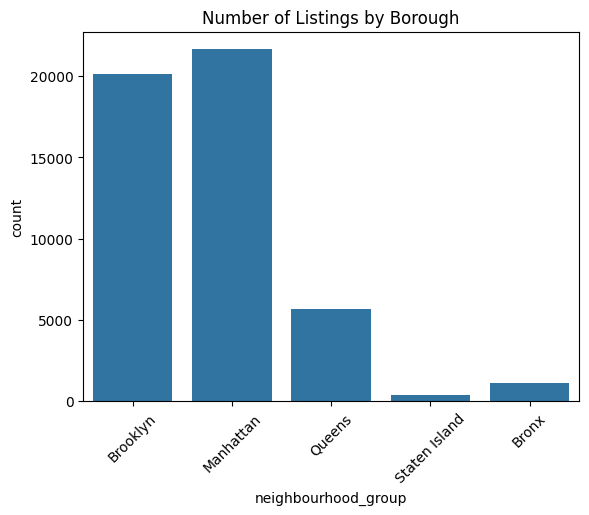

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='neighbourhood_group', data=df)
plt.title('Number of Listings by Borough')
plt.xticks(rotation=45)
plt.show()

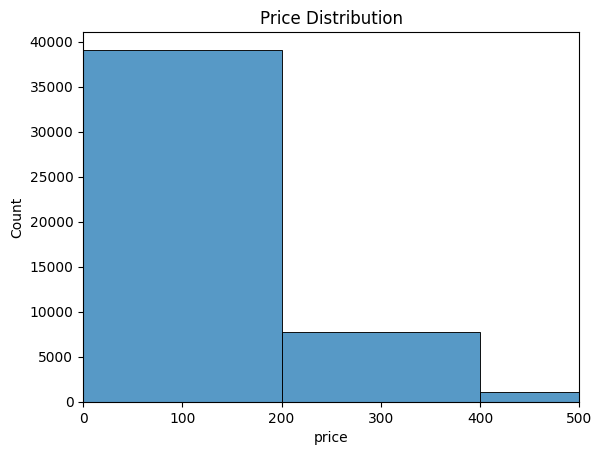

In [6]:
sns.histplot(df['price'], bins=50)
plt.xlim(0, 500)  # limit for better visibility
plt.title('Price Distribution')
plt.show()

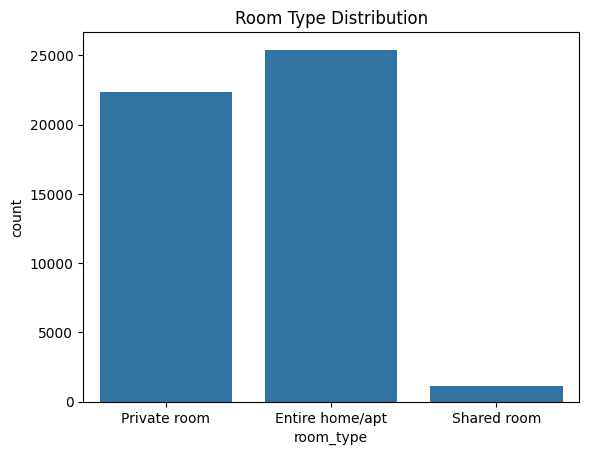

In [7]:
sns.countplot(x='room_type', data=df)
plt.title('Room Type Distribution')
plt.show()

insights
Popular listings with more reviews tend to have less availability
Manhattan and Brooklyn dominate the market
Other boroughs like Bronx and Staten Island have far fewer listings

What it means: